# Analisi degli Incidenti Stradali in Italia

## Obiettivo del progetto

L'obiettivo del progetto è analizzare gli incidenti stradali nei comuni italiani utilizzando i dati ufficiali ISTAT e il dataset territoriale SITUAS.

Il progetto comprende:

- acquisizione automatica dei dati tramite API ISTAT;
- comprensione e pulizia dei dati;
- integrazione con le informazioni territoriali SITUAS;
- creazione di un dataset arricchito;
- analisi esplorativa dei dati;
- realizzazione di una dashboard interattiva in Power BI.

## 1. Import delle librerie

Vengono importate le librerie necessarie per l'acquisizione, la manipolazione, l'analisi e la visualizzazione dei dati.

In [1]:
import pandas as pd
import numpy as np

import requests
from io import StringIO

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## 2. Acquisizione dei dati ISTAT

I dati sugli incidenti stradali vengono acquisiti automaticamente tramite l'API ufficiale ISTAT.

In caso di indisponibilità temporanea del servizio, il notebook utilizza una copia locale dell'ultimo dataset scaricato, garantendo la continuità dell'elaborazione.

In [2]:
url = "https://esploradati.istat.it/SDMXWS/rest/data/41_983"

headers = {
    "Accept": "application/vnd.sdmx.data+csv;version=1.0.0"
}

try:
    response = requests.get(
        url,
        headers=headers,
        timeout=120
    )

    print("Status code:", response.status_code)
    response.raise_for_status()

    df_istat = pd.read_csv(
        StringIO(response.text),
        low_memory=False
    )

    print("Dati scaricati dall'API ISTAT.")

except requests.exceptions.RequestException as errore:
    print("API ISTAT temporaneamente non disponibile.")
    print("Errore:", errore)
    print("Caricamento della copia locale.")

    df_istat = pd.read_csv(
        "../data/raw/istat_incidenti_raw.csv",
        low_memory=False
    )

print("Dimensioni:", df_istat.shape)
display(df_istat.head())

Status code: 200
Dati scaricati dall'API ISTAT.
Dimensioni: (573552, 16)


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Comprensione del dataset

In questa sezione vengono analizzate la struttura del dataset ISTAT, le tipologie delle variabili e la presenza di eventuali valori mancanti prima delle operazioni di pulizia e integrazione.

In [3]:
display(df_istat.head())
df_istat.info()

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DATAFLOW          573552 non-null  str    
 1   FREQ              573552 non-null  str    
 2   REF_AREA          573552 non-null  int64  
 3   DATA_TYPE         573552 non-null  str    
 4   RESULT            573552 non-null  str    
 5   TIME_PERIOD       573552 non-null  int64  
 6   OBS_VALUE         573552 non-null  int64  
 7   OBS_STATUS        0 non-null       float64
 8   NOTE_DS           0 non-null       float64
 9   NOTE_REF_AREA     0 non-null       float64
 10  NOTE_DATA_TYPE    0 non-null       float64
 11  NOTE_RESULT       0 non-null       float64
 12  NOTE_TIME_PERIOD  0 non-null       float64
 13  BASE_PER          0 non-null       float64
 14  UNIT_MEAS         0 non-null       float64
 15  UNIT_MULT         0 non-null       float64
dtypes: float64(9), int64(3), str(4)

In [4]:
print("Numero di righe e colonne:", df_istat.shape)

Numero di righe e colonne: (573552, 16)


In [5]:
print("\nColonne:")
print(df_istat.columns.tolist())


Colonne:
['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'NOTE_DS', 'NOTE_REF_AREA', 'NOTE_DATA_TYPE', 'NOTE_RESULT', 'NOTE_TIME_PERIOD', 'BASE_PER', 'UNIT_MEAS', 'UNIT_MULT']


In [6]:
print("\nValori mancanti:")
display(df_istat.isnull().sum())


Valori mancanti:


DATAFLOW                 0
FREQ                     0
REF_AREA                 0
DATA_TYPE                0
RESULT                   0
TIME_PERIOD              0
OBS_VALUE                0
OBS_STATUS          573552
NOTE_DS             573552
NOTE_REF_AREA       573552
NOTE_DATA_TYPE      573552
NOTE_RESULT         573552
NOTE_TIME_PERIOD    573552
BASE_PER            573552
UNIT_MEAS           573552
UNIT_MULT           573552
dtype: int64

## 4. Controlli preliminari sulla qualità dei dati

In questa fase vengono verificati:

- eventuali record duplicati;
- tipi di dato delle variabili;
- coerenza delle colonne;
- presenza di valori mancanti.

Questi controlli permettono di preparare il dataset alle successive operazioni di integrazione.

In [7]:
print("Righe duplicate:", df_istat.duplicated().sum())

Righe duplicate: 0


In [8]:
df_istat.dtypes

DATAFLOW                str
FREQ                    str
REF_AREA              int64
DATA_TYPE               str
RESULT                  str
TIME_PERIOD           int64
OBS_VALUE             int64
OBS_STATUS          float64
NOTE_DS             float64
NOTE_REF_AREA       float64
NOTE_DATA_TYPE      float64
NOTE_RESULT         float64
NOTE_TIME_PERIOD    float64
BASE_PER            float64
UNIT_MEAS           float64
UNIT_MULT           float64
dtype: object

## 5. Caricamento del dataset SITUAS

Il dataset SITUAS contiene informazioni territoriali e anagrafiche relative ai comuni italiani.

Tra le variabili disponibili sono presenti:

- codice del comune;
- nome del comune;
- provincia;
- popolazione residente;
- superficie territoriale.

Queste informazioni vengono utilizzate per arricchire il dataset ISTAT.

In [9]:
df_situas = pd.read_csv(
    "../data/raw/Comuni - Dimensione Data Indagine 28-07-2026.csv",
    sep=";"
)

display(df_situas.head())
df_situas.info()

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente)
0,1,1,1,201,1001,1001,Agliè,NaN,TO,0,0,2562,2021,"13,1463",2026,2585,2024
1,1,1,1,201,1002,1002,Airasca,NaN,TO,0,0,3660,2021,"15,7393",2026,3695,2024
2,1,1,1,201,1003,1003,Ala di Stura,NaN,TO,0,0,467,2021,"46,3316",2026,463,2024
3,1,1,1,201,1004,1004,Albiano d'Ivrea,NaN,TO,0,0,1637,2021,"11,7397",2026,1624,2024
4,1,1,1,201,1006,1006,Almese,NaN,TO,0,0,6331,2021,"17,8741",2026,6297,2024


<class 'pandas.DataFrame'>
RangeIndex: 7894 entries, 0 to 7893
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Codice Ripartizione geografica  7894 non-null   int64
 1   Codice Regione                  7894 non-null   int64
 2   Codice Provincia (Storico)      7894 non-null   int64
 3   Codice Provincia/Uts            7894 non-null   int64
 4   Codice Comune (alfanumerico)    7894 non-null   int64
 5   Codice Comune (numerico)        7894 non-null   int64
 6   Comune                          7893 non-null   str  
 7   Comune (dizione straniera)      124 non-null    str  
 8   Sigla automobilistica           7802 non-null   str  
 9   Capoluogo di Provincia/Uts      7894 non-null   int64
 10  Capoluogo di Regione            7894 non-null   int64
 11  Popolazione legale              7894 non-null   int64
 12  Anno Censimento                 7894 non-null   int64
 13  Superficie (Km

In [10]:
df_situas.columns.tolist()

['Codice Ripartizione geografica',
 'Codice Regione',
 'Codice Provincia (Storico)',
 'Codice Provincia/Uts',
 'Codice Comune (alfanumerico)',
 'Codice Comune (numerico)',
 'Comune',
 'Comune (dizione straniera)',
 'Sigla automobilistica',
 'Capoluogo di Provincia/Uts',
 'Capoluogo di Regione',
 'Popolazione legale',
 'Anno Censimento',
 'Superficie (Kmq)',
 'Anno (Superficie)',
 'Popolazione residente',
 'Anno (Popolazione residente)']

## 6. Preparazione delle chiavi di integrazione

Il collegamento tra i due dataset avviene tramite il codice comunale.

Poiché i codici possono essere letti con lunghezze differenti a causa della perdita degli zeri iniziali, entrambe le chiavi vengono convertite in formato testuale e uniformate a sei cifre.

In [11]:
print("REF_AREA - tipo:")
print(df_istat["REF_AREA"].dtype)

print("\nEsempi REF_AREA:")
print(df_istat["REF_AREA"].dropna().astype(str).head(10).tolist())

print("\nCodice Comune numerico - tipo:")
print(df_situas["Codice Comune (numerico)"].dtype)

print("\nEsempi Codice Comune:")
print(
    df_situas["Codice Comune (numerico)"]
    .dropna()
    .astype(str)
    .head(10)
    .tolist()
)

REF_AREA - tipo:
int64

Esempi REF_AREA:
['1001', '1001', '1001', '1001', '1001', '1001', '1001', '1001', '1001', '1001']

Codice Comune numerico - tipo:
int64

Esempi Codice Comune:
['1001', '1002', '1003', '1004', '1006', '1007', '1008', '1009', '1010', '1011']


In [12]:
print("Lunghezze REF_AREA:")
print(
    df_istat["REF_AREA"]
    .dropna()
    .astype(str)
    .str.len()
    .value_counts()
    .sort_index()
)

print("\nLunghezze Codice Comune:")
print(
    df_situas["Codice Comune (numerico)"]
    .dropna()
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.len()
    .value_counts()
    .sort_index()
)

Lunghezze REF_AREA:
REF_AREA
4     88968
5    462675
6     21909
Name: count, dtype: int64

Lunghezze Codice Comune:
Codice Comune (numerico)
4    1241
5    6013
6     640
Name: count, dtype: int64


In [13]:
df_istat["codice_comune"] = (
    df_istat["REF_AREA"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

df_situas["codice_comune"] = (
    df_situas["Codice Comune (numerico)"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(6)
)

In [14]:
codici_situas = set(df_situas["codice_comune"].dropna())

df_istat["comune_trovato"] = df_istat["codice_comune"].isin(codici_situas)

print(df_istat["comune_trovato"].value_counts())
print("\nPercentuale di righe abbinate:")
print(df_istat["comune_trovato"].mean() * 100)

comune_trovato
True     527511
False     46041
Name: count, dtype: int64

Percentuale di righe abbinate:
91.97265461544899


### Verifica della corrispondenza dei codici

Prima di effettuare il merge viene verificata la percentuale di codici ISTAT presenti anche nel dataset SITUAS.

I codici non associati vengono analizzati separatamente per individuare eventuali comuni storici, soppressi o soggetti a variazioni amministrative.

In [45]:
non_abbinati = (
    df_istat.loc[
        ~df_istat["comune_trovato"],
        ["REF_AREA", "codice_comune"]
    ]
    .drop_duplicates()
    .sort_values("codice_comune")
)

print("Righe ISTAT non abbinate:", (~df_istat["comune_trovato"]).sum())
print("Codici distinti non abbinati:", non_abbinati.shape[0])

display(non_abbinati.head(30))

Righe ISTAT non abbinate: 46041
Codici distinti non abbinati: 1062


,REF_AREA,codice_comune
288,1005,001005
9750,1138,001138
10650,1151,001151
12834,1182,001182
19599,1277,001277
21000,1297,001297
23262,2019,002019
23880,2038,002038
26478,2111,002111
26529,2112,002112


In [16]:
non_abbinati_per_anno = (
    df_istat.loc[~df_istat["comune_trovato"]]
    .groupby("TIME_PERIOD")
    .size()
    .reset_index(name="righe_non_abbinate")
    .sort_values("TIME_PERIOD")
)

display(non_abbinati_per_anno)

,TIME_PERIOD,righe_non_abbinate
0,2001,2487
1,2002,2487
2,2003,2487
3,2004,2481
4,2005,2481
5,2006,2481
6,2007,2481
7,2008,2481
8,2009,2475
9,2010,2115


## 7. Arricchimento del dataset

Il dataset ISTAT viene integrato con il dataset SITUAS mediante una join sul codice comunale.

L'operazione aggiunge le seguenti informazioni:

- nome del comune;
- codice della regione;
- codice della provincia;
- sigla automobilistica;
- popolazione residente;
- superficie comunale.

Viene utilizzata una left join per conservare tutte le osservazioni originali del dataset ISTAT, comprese quelle per cui non è disponibile una corrispondenza nel dataset territoriale.

In [44]:
colonne_comuni = [
    "codice_comune",
    "Comune",
    "Codice Regione",
    "Codice Provincia/Uts",
    "Sigla automobilistica",
    "Popolazione residente",
    "Superficie (Kmq)"
]

df_finale = df_istat.merge(
    df_situas[colonne_comuni],
    on="codice_comune",
    how="left",
    validate="many_to_one"
)

### Verifica del dataset arricchito

Dopo il merge vengono controllate:

- le dimensioni del dataset;
- la presenza delle nuove colonne;
- la conservazione del numero di righe;
- la quantità di comuni non associati.

In [18]:
print(df_finale.shape)
display(df_finale.head())
df_finale.info()

(573552, 24)


,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,...,UNIT_MEAS,UNIT_MULT,codice_comune,comune_trovato,Comune,Codice Regione,Codice Provincia/Uts,Sigla automobilistica,Popolazione residente,Superficie (Kmq)
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,...,NaN,NaN,001001,True,Agliè,1.0,201.0,TO,2585.0,"13,1463"
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,...,NaN,NaN,001001,True,Agliè,1.0,201.0,TO,2585.0,"13,1463"
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,...,NaN,NaN,001001,True,Agliè,1.0,201.0,TO,2585.0,"13,1463"
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,...,NaN,NaN,001001,True,Agliè,1.0,201.0,TO,2585.0,"13,1463"
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,...,NaN,NaN,001001,True,Agliè,1.0,201.0,TO,2585.0,"13,1463"


<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DATAFLOW               573552 non-null  str    
 1   FREQ                   573552 non-null  str    
 2   REF_AREA               573552 non-null  int64  
 3   DATA_TYPE              573552 non-null  str    
 4   RESULT                 573552 non-null  str    
 5   TIME_PERIOD            573552 non-null  int64  
 6   OBS_VALUE              573552 non-null  int64  
 7   OBS_STATUS             0 non-null       float64
 8   NOTE_DS                0 non-null       float64
 9   NOTE_REF_AREA          0 non-null       float64
 10  NOTE_DATA_TYPE         0 non-null       float64
 11  NOTE_RESULT            0 non-null       float64
 12  NOTE_TIME_PERIOD       0 non-null       float64
 13  BASE_PER               0 non-null       float64
 14  UNIT_MEAS              0 non-null       float64

## 7. Pulizia e standardizzazione finale

Prima dell'esportazione vengono eseguite le ultime trasformazioni:

- eliminazione delle colonne tecniche utilizzate per il merge;
- conversione della superficie in formato numerico;
- standardizzazione dei nomi delle colonne;
- gestione dei comuni e delle province non associate.

In [19]:
df_finale = df_finale.drop(columns=["codice_comune"])

In [20]:
df_finale = df_finale.drop(
    columns=["comune_trovato"],
    errors="ignore"
)

In [21]:
df_finale.info()
display(df_finale.head())

<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   DATAFLOW               573552 non-null  str    
 1   FREQ                   573552 non-null  str    
 2   REF_AREA               573552 non-null  int64  
 3   DATA_TYPE              573552 non-null  str    
 4   RESULT                 573552 non-null  str    
 5   TIME_PERIOD            573552 non-null  int64  
 6   OBS_VALUE              573552 non-null  int64  
 7   OBS_STATUS             0 non-null       float64
 8   NOTE_DS                0 non-null       float64
 9   NOTE_REF_AREA          0 non-null       float64
 10  NOTE_DATA_TYPE         0 non-null       float64
 11  NOTE_RESULT            0 non-null       float64
 12  NOTE_TIME_PERIOD       0 non-null       float64
 13  BASE_PER               0 non-null       float64
 14  UNIT_MEAS              0 non-null       float64

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,...,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,Comune,Codice Regione,Codice Provincia/Uts,Sigla automobilistica,Popolazione residente,Superficie (Kmq)
0,IT1:41_983(1.0),A,1001,KILLINJ,F,2001,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Agliè,1.0,201.0,TO,2585.0,"13,1463"
1,IT1:41_983(1.0),A,1001,KILLINJ,F,2002,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Agliè,1.0,201.0,TO,2585.0,"13,1463"
2,IT1:41_983(1.0),A,1001,KILLINJ,F,2003,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Agliè,1.0,201.0,TO,2585.0,"13,1463"
3,IT1:41_983(1.0),A,1001,KILLINJ,F,2004,13,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Agliè,1.0,201.0,TO,2585.0,"13,1463"
4,IT1:41_983(1.0),A,1001,KILLINJ,F,2005,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Agliè,1.0,201.0,TO,2585.0,"13,1463"


In [22]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

print("Dataset ok")

Dataset ok


In [23]:
list(Path("../data/processed").glob("*.csv"))

[WindowsPath('../data/processed/incidenti_istat_clean.csv'),
 WindowsPath('../data/processed/incidenti_istat_enriched.csv')]

In [24]:
df_finale["Superficie (Kmq)"] = pd.to_numeric(
    df_finale["Superficie (Kmq)"]
    .astype("string")
    .str.strip()
    .str.replace(",", ".", regex=False),
    errors="coerce"
)

In [25]:
print(df_finale["Superficie (Kmq)"].dtype)
print(
    "Superfici mancanti:",
    df_finale["Superficie (Kmq)"].isna().sum()
)

Float64
Superfici mancanti: 46113


In [26]:
print(df_finale.columns.tolist())

['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'NOTE_DS', 'NOTE_REF_AREA', 'NOTE_DATA_TYPE', 'NOTE_RESULT', 'NOTE_TIME_PERIOD', 'BASE_PER', 'UNIT_MEAS', 'UNIT_MULT', 'Comune', 'Codice Regione', 'Codice Provincia/Uts', 'Sigla automobilistica', 'Popolazione residente', 'Superficie (Kmq)']


In [27]:
df_finale = df_finale.rename(columns={
    "Comune": "COMUNE",
    "Sigla automobilistica": "PROVINCIA",
    "Popolazione residente": "POPOLAZIONE",
    "Superficie (Kmq)": "SUPERFICIE_KMQ"
})

In [28]:
import pandas as pd

df_check = pd.read_csv("../data/processed/incidenti_istat_enriched.csv")

print(df_check.columns.tolist())

['DATAFLOW', 'FREQ', 'REF_AREA', 'DATA_TYPE', 'RESULT', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_STATUS', 'NOTE_DS', 'NOTE_REF_AREA', 'NOTE_DATA_TYPE', 'NOTE_RESULT', 'NOTE_TIME_PERIOD', 'BASE_PER', 'UNIT_MEAS', 'UNIT_MULT', 'COMUNE', 'Codice Regione', 'Codice Provincia/Uts', 'PROVINCIA', 'POPOLAZIONE', 'SUPERFICIE_KMQ']


In [29]:
df_finale["COMUNE"] = df_finale["COMUNE"].fillna("Comune non associato")

df_finale["PROVINCIA"] = df_finale["PROVINCIA"].fillna("Non disponibile")

## 8. Esportazione del dataset finale

Il dataset arricchito e standardizzato viene salvato nella cartella `data/processed`.

Il file `incidenti_istat_enriched.csv` rappresenta la sorgente utilizzata dalla dashboard Power BI.

In [30]:
df_finale.to_csv(
    "../data/processed/incidenti_istat_enriched.csv",
    index=False
)

# 9. Analisi Esplorativa dei Dati (EDA)

Una volta completata la fase di acquisizione, pulizia e arricchimento del dataset, viene effettuata un'Analisi Esplorativa dei Dati (Exploratory Data Analysis - EDA).

L'obiettivo è comprendere le principali caratteristiche del fenomeno degli incidenti stradali in Italia, individuando trend temporali, distribuzioni e relazioni tra le variabili.

Le analisi presentate in questa sezione costituiscono la base delle visualizzazioni sviluppate nella dashboard Power BI.

## 9.1 Panoramica del dataset

Prima di procedere con le analisi esplorative vengono riepilogate le principali caratteristiche del dataset finale ottenuto dopo la fase di integrazione e pulizia.

In [31]:
df = pd.read_csv("../data/processed/incidenti_istat_enriched.csv")

print(f"Numero di osservazioni: {len(df):,}")
print(f"Numero di variabili: {len(df.columns)}")

df.info()

Numero di osservazioni: 573,552
Numero di variabili: 22
<class 'pandas.DataFrame'>
RangeIndex: 573552 entries, 0 to 573551
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   DATAFLOW              573552 non-null  str    
 1   FREQ                  573552 non-null  str    
 2   REF_AREA              573552 non-null  int64  
 3   DATA_TYPE             573552 non-null  str    
 4   RESULT                573552 non-null  str    
 5   TIME_PERIOD           573552 non-null  int64  
 6   OBS_VALUE             573552 non-null  int64  
 7   OBS_STATUS            0 non-null       float64
 8   NOTE_DS               0 non-null       float64
 9   NOTE_REF_AREA         0 non-null       float64
 10  NOTE_DATA_TYPE        0 non-null       float64
 11  NOTE_RESULT           0 non-null       float64
 12  NOTE_TIME_PERIOD      0 non-null       float64
 13  BASE_PER              0 non-null       float64
 14  UNIT_ME

## 9.2 Statistiche descrittive

Vengono analizzate le principali statistiche descrittive delle variabili numeriche del dataset, al fine di ottenere una panoramica generale delle osservazioni disponibili.

In [32]:
df.describe()

,REF_AREA,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,Codice Regione,Codice Provincia/Uts,POPOLAZIONE,SUPERFICIE_KMQ
count,573552.000000,573552.000000,573552.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,527511.000000,527511.000000,5.275110e+05,527439.000000
mean,44528.628771,2012.340541,20.207603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.134113,76.036722,7.686696e+03,36.733377
std,32093.886203,6.859876,245.813966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.027009,80.913995,4.299589e+04,47.673471
min,1001.000000,2001.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,2.000000,3.200000e+01,0.122200
25%,16137.000000,2006.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,18.000000,1.000000e+03,11.230000
50%,38012.500000,2012.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,54.000000,2.455000e+03,21.750700
75%,71052.000000,2018.000000,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.000000,86.000000,6.394000e+03,42.580300
max,111107.000000,2024.000000,30254.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.000000,287.000000,2.747290e+06,653.674800


## 9.3 Andamento degli incidenti nel tempo

L'analisi mostra l'evoluzione del numero complessivo di incidenti stradali registrati nel periodo considerato.

Per questa analisi vengono considerate esclusivamente le osservazioni relative agli incidenti stradali (`DATA_TYPE = ROADACC`).

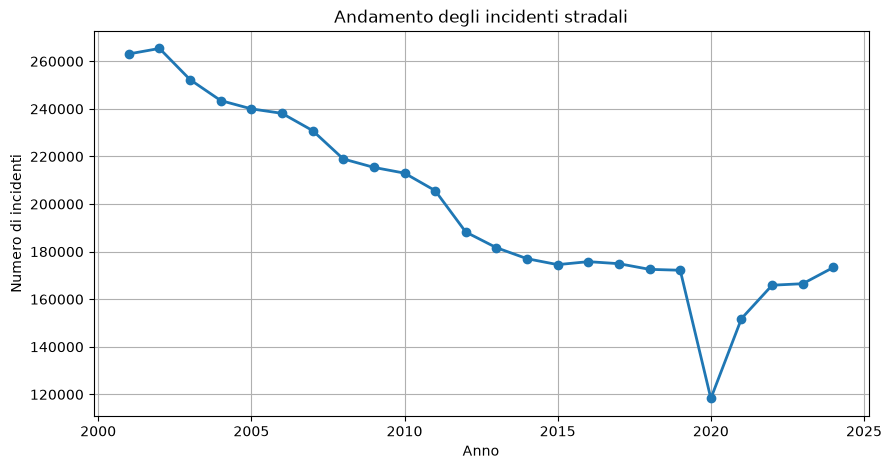

In [33]:
incidenti_annuali = (
    df[df["DATA_TYPE"] == "ROADACC"]
      .groupby("TIME_PERIOD")["OBS_VALUE"]
      .sum()
)

plt.figure(figsize=(10,5))

plt.plot(
    incidenti_annuali.index,
    incidenti_annuali.values,
    marker="o",
    linewidth=2
)

plt.title("Andamento degli incidenti stradali")
plt.xlabel("Anno")
plt.ylabel("Numero di incidenti")
plt.grid(True)

plt.show()

**Osservazione**

Il grafico evidenzia l'evoluzione temporale degli incidenti stradali e permette di individuare eventuali variazioni significative nel periodo analizzato.

## 9.4 Distribuzione di morti e feriti

Vengono confrontati i principali indicatori relativi alle conseguenze degli incidenti.

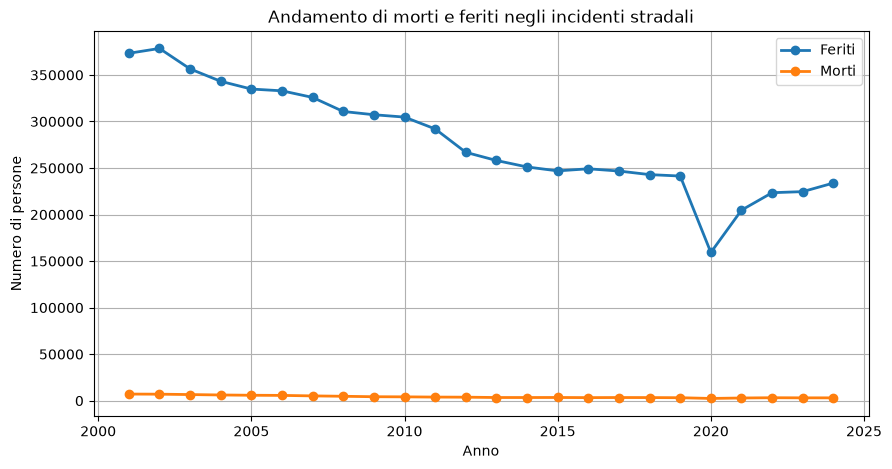

In [34]:
morti_feriti = (
    df[df["DATA_TYPE"] == "KILLINJ"]
    .pivot_table(
        index="TIME_PERIOD",
        columns="RESULT",
        values="OBS_VALUE",
        aggfunc="sum"
    )
)

morti_feriti = morti_feriti.rename(
    columns={
        "F": "Feriti",
        "M": "Morti"
    }
)

plt.figure(figsize=(10,5))

plt.plot(
    morti_feriti.index,
    morti_feriti["Feriti"],
    marker="o",
    linewidth=2,
    label="Feriti"
)

plt.plot(
    morti_feriti.index,
    morti_feriti["Morti"],
    marker="o",
    linewidth=2,
    label="Morti"
)

plt.title("Andamento di morti e feriti negli incidenti stradali")
plt.xlabel("Anno")
plt.ylabel("Numero di persone")
plt.grid(True)
plt.legend()

plt.show()

## 9.5 Comuni con il maggior numero di incidenti

Per individuare i territori maggiormente interessati dal fenomeno vengono analizzati i comuni che registrano il maggior numero complessivo di incidenti nel periodo osservato.

L'analisi considera esclusivamente gli incidenti stradali (`DATA_TYPE = ROADACC`) e permette di evidenziare i comuni con la più elevata concentrazione di eventi.

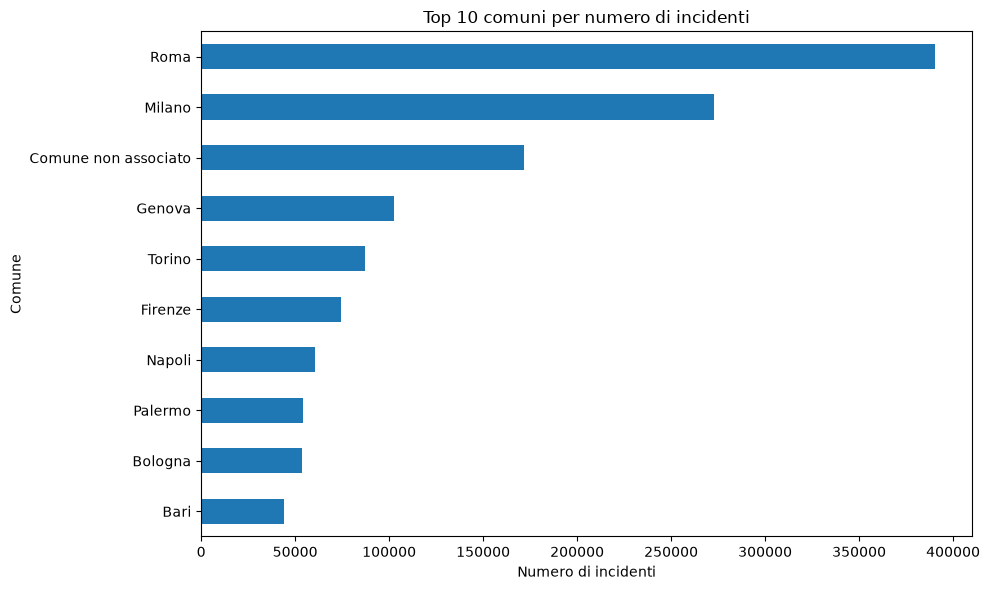

In [35]:
top_comuni = (
    df[df["DATA_TYPE"] == "ROADACC"]
    .groupby("COMUNE")["OBS_VALUE"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

top_comuni.sort_values().plot(kind="barh")

plt.title("Top 10 comuni per numero di incidenti")
plt.xlabel("Numero di incidenti")
plt.ylabel("Comune")

plt.tight_layout()
plt.show()

**Osservazione**

I comuni con il maggior numero di incidenti coincidono prevalentemente con i principali centri urbani italiani. Questo risultato è coerente con la maggiore densità abitativa, l'elevato volume di traffico e la presenza di infrastrutture stradali più estese rispetto ai comuni di dimensioni minori.

## 9.6 Incidenti per 1.000 abitanti

Il numero assoluto di incidenti è fortemente influenzato dalla dimensione demografica dei comuni.

Per confrontare territori con popolazioni differenti viene calcolato il numero di incidenti ogni 1.000 abitanti, ottenendo un indicatore normalizzato che permette confronti più significativi.

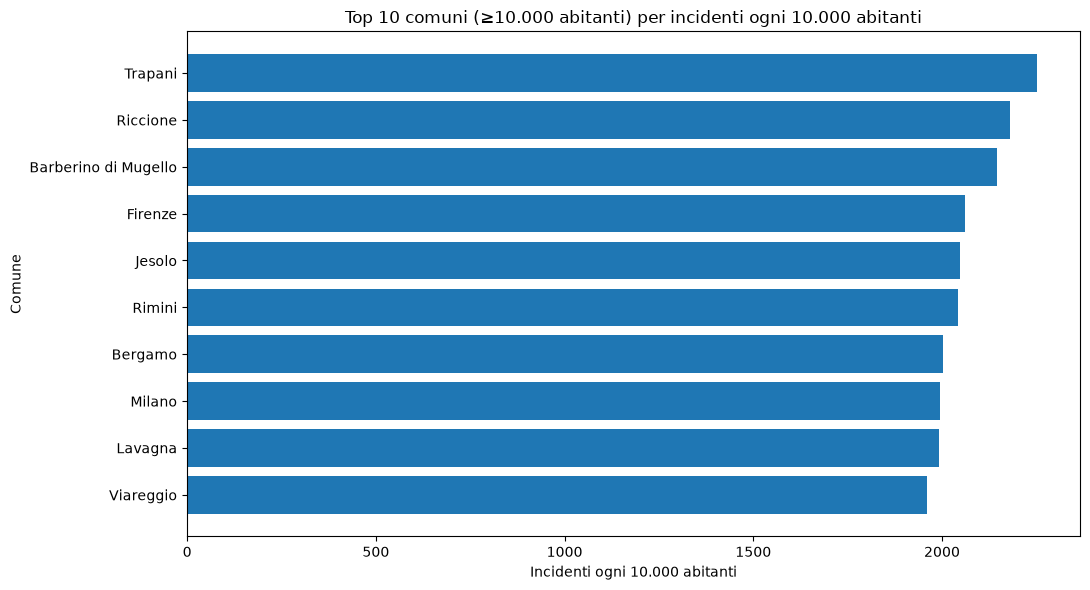

In [36]:
incidenti_pop = (
    df[df["DATA_TYPE"] == "ROADACC"]
    .groupby(["COMUNE", "POPOLAZIONE"], as_index=False)["OBS_VALUE"]
    .sum()
)

incidenti_pop["Incidenti_per_10000_ab"] = (
    incidenti_pop["OBS_VALUE"] /
    incidenti_pop["POPOLAZIONE"] * 10000
)

# Consideriamo solo i comuni con almeno 10.000 abitanti
incidenti_pop = incidenti_pop[
    (incidenti_pop["POPOLAZIONE"] >= 10000) &
    (incidenti_pop["COMUNE"] != "Comune non associato")
]

top_10000 = (
    incidenti_pop
    .sort_values("Incidenti_per_10000_ab", ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

plt.barh(
    top_10000["COMUNE"],
    top_10000["Incidenti_per_10000_ab"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 comuni (≥10.000 abitanti) per incidenti ogni 10.000 abitanti")
plt.xlabel("Incidenti ogni 10.000 abitanti")
plt.ylabel("Comune")

plt.tight_layout()
plt.show()

**Osservazione**

L'utilizzo di un indicatore normalizzato consente di confrontare comuni con dimensioni demografiche differenti. Limitando l'analisi ai comuni con almeno 10.000 abitanti, la classifica risulta più rappresentativa ed evita che piccoli comuni con pochi residenti producano valori anomali dovuti a effetti statistici.

## 9.7 Densità degli incidenti

Oltre alla popolazione residente, anche l'estensione territoriale può influenzare l'interpretazione del numero di incidenti.

Per questo motivo viene calcolato un indicatore che misura il numero di incidenti per chilometro quadrato, consentendo di confrontare comuni con superfici differenti.

Per garantire risultati più rappresentativi, vengono considerati esclusivamente i comuni con almeno 10.000 abitanti.

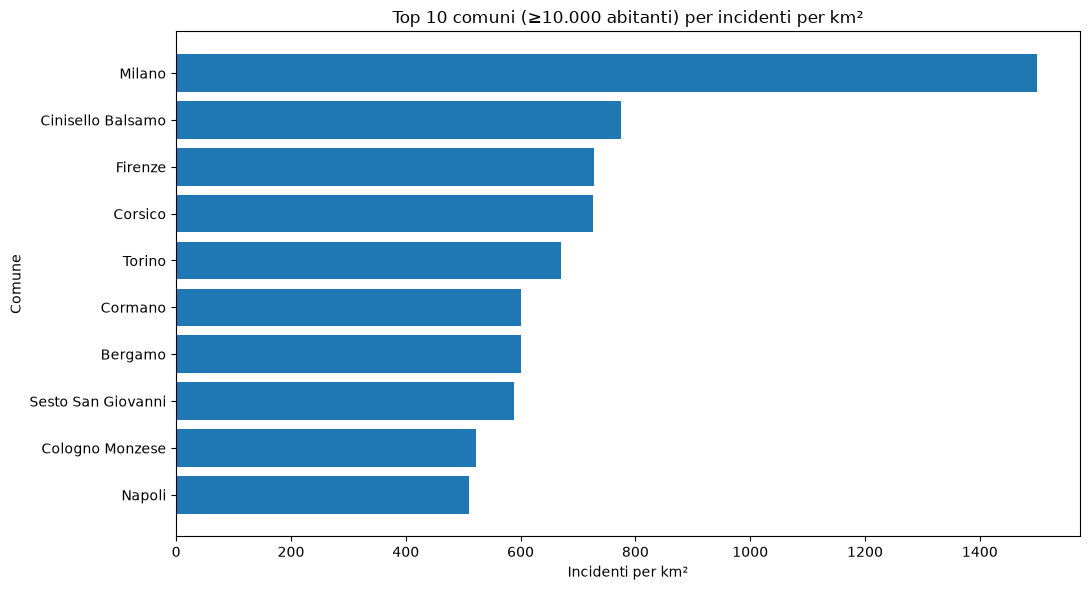

In [37]:
incidenti_sup = (
    df[df["DATA_TYPE"] == "ROADACC"]
    .groupby(
        ["COMUNE", "POPOLAZIONE", "SUPERFICIE_KMQ"],
        as_index=False
    )["OBS_VALUE"]
    .sum()
)

incidenti_sup = incidenti_sup[
    (incidenti_sup["POPOLAZIONE"] >= 10000) &
    (incidenti_sup["SUPERFICIE_KMQ"] > 0) &
    (incidenti_sup["COMUNE"] != "Comune non associato")
]

incidenti_sup["Incidenti_per_kmq"] = (
    incidenti_sup["OBS_VALUE"] /
    incidenti_sup["SUPERFICIE_KMQ"]
)

top_kmq = (
    incidenti_sup
    .sort_values("Incidenti_per_kmq", ascending=False)
    .head(10)
)

plt.figure(figsize=(11,6))

plt.barh(
    top_kmq["COMUNE"],
    top_kmq["Incidenti_per_kmq"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 comuni (≥10.000 abitanti) per incidenti per km²")
plt.xlabel("Incidenti per km²")
plt.ylabel("Comune")

plt.tight_layout()
plt.show()


## 9.8 Incidenti medi per fascia di popolazione

Per rendere più leggibile la relazione tra dimensione demografica e incidentalità, i comuni vengono suddivisi in fasce di popolazione.

Per ciascuna fascia viene calcolato il numero medio complessivo di incidenti registrati nel periodo analizzato.

L'analisi considera esclusivamente i comuni con almeno 10.000 abitanti e le osservazioni relative agli incidenti stradali (`DATA_TYPE = ROADACC`).

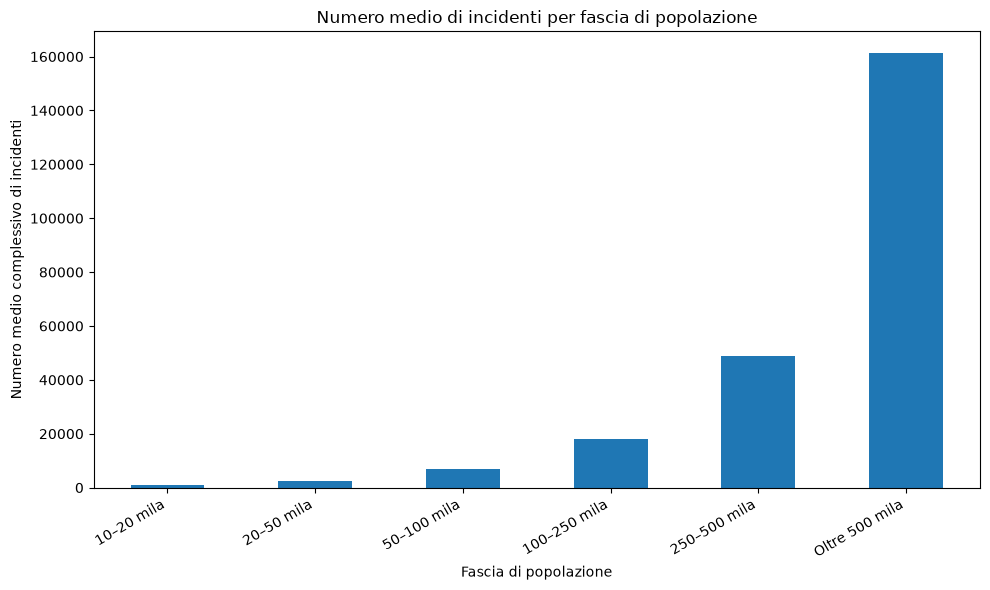

In [38]:
incidenti_fasce = (
    df[df["DATA_TYPE"] == "ROADACC"]
    .groupby(
        ["COMUNE", "POPOLAZIONE"],
        as_index=False
    )["OBS_VALUE"]
    .sum()
)

incidenti_fasce = incidenti_fasce[
    (incidenti_fasce["POPOLAZIONE"] >= 10000) &
    (incidenti_fasce["COMUNE"] != "Comune non associato")
].copy()

fasce = [
    10000,
    20000,
    50000,
    100000,
    250000,
    500000,
    float("inf")
]

etichette = [
    "10–20 mila",
    "20–50 mila",
    "50–100 mila",
    "100–250 mila",
    "250–500 mila",
    "Oltre 500 mila"
]

incidenti_fasce["Fascia_popolazione"] = pd.cut(
    incidenti_fasce["POPOLAZIONE"],
    bins=fasce,
    labels=etichette,
    right=False
)

media_per_fascia = (
    incidenti_fasce
    .groupby("Fascia_popolazione", observed=True)["OBS_VALUE"]
    .mean()
)

plt.figure(figsize=(10, 6))

media_per_fascia.plot(kind="bar")

plt.title("Numero medio di incidenti per fascia di popolazione")
plt.xlabel("Fascia di popolazione")
plt.ylabel("Numero medio complessivo di incidenti")
plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

# 10. Conclusioni

Il progetto ha consentito di realizzare una pipeline completa per l'acquisizione, l'integrazione e l'analisi dei dati relativi agli incidenti stradali in Italia.

I dati sono stati acquisiti automaticamente tramite le API ISTAT, successivamente arricchiti con informazioni territoriali e demografiche provenienti dal dataset SITUAS, ottenendo un dataset finale più completo e adatto alle analisi.

L'Analisi Esplorativa dei Dati ha evidenziato l'evoluzione temporale degli incidenti, delle persone ferite e decedute, oltre a mettere in luce le differenze territoriali tra i comuni italiani attraverso indicatori assoluti e normalizzati.

Il dataset elaborato costituisce la base della dashboard interattiva sviluppata in Power BI, che consente di esplorare i dati mediante filtri dinamici e visualizzazioni interattive. Grazie all'utilizzo delle API, l'intero processo di aggiornamento risulta facilmente ripetibile: è sufficiente rieseguire il notebook e aggiornare la dashboard affinché vengano utilizzati i dati più recenti resi disponibili da ISTAT.

Come possibili sviluppi futuri, il progetto potrebbe essere esteso integrando ulteriori sorgenti informative, quali dati meteorologici, flussi di traffico o caratteristiche della rete stradale, al fine di approfondire i fattori che influenzano l'incidentalità e sviluppare analisi predittive più avanzate.

In [39]:
df[df["COMUNE"].str.contains("Cagliari", case=False, na=False)]

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,...,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,COMUNE,Codice Regione,Codice Provincia/Uts,PROVINCIA,POPOLAZIONE,SUPERFICIE_KMQ


In [40]:
print(df_istat["REF_AREA"].min(), df_istat["REF_AREA"].max())

1001 111107


In [41]:
df_istat[df_istat["REF_AREA"].astype(str).str.startswith("20")]

,DATAFLOW,FREQ,REF_AREA,DATA_TYPE,RESULT,TIME_PERIOD,OBS_VALUE,OBS_STATUS,NOTE_DS,NOTE_REF_AREA,NOTE_DATA_TYPE,NOTE_RESULT,NOTE_TIME_PERIOD,BASE_PER,UNIT_MEAS,UNIT_MULT,codice_comune,comune_trovato
22404,IT1:41_983(1.0),A,2002,KILLINJ,F,2001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,002002,True
22405,IT1:41_983(1.0),A,2002,KILLINJ,F,2002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,002002,True
22406,IT1:41_983(1.0),A,2002,KILLINJ,F,2003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,002002,True
22407,IT1:41_983(1.0),A,2002,KILLINJ,F,2004,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,002002,True
22408,IT1:41_983(1.0),A,2002,KILLINJ,F,2005,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,002002,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192523,IT1:41_983(1.0),A,20073,ROADACC,9,2020,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,020073,True
192524,IT1:41_983(1.0),A,20073,ROADACC,9,2021,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,020073,True
192525,IT1:41_983(1.0),A,20073,ROADACC,9,2022,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,020073,True
192526,IT1:41_983(1.0),A,20073,ROADACC,9,2023,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,020073,True


In [42]:
df_situas[df_situas["Comune"].str.contains("Cagliari", case=False, na=False)]

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente),codice_comune
7805,5,20,118,318,118006,118006,Cagliari,NaN,CA,1,1,149092,2021,"84,8236",2026,146692,2024,118006


In [43]:
df_situas[df_situas["Sigla automobilistica"].isin(["CA", "SS", "NU", "OR", "SU"])]

,Codice Ripartizione geografica,Codice Regione,Codice Provincia (Storico),Codice Provincia/Uts,Codice Comune (alfanumerico),Codice Comune (numerico),Comune,Comune (dizione straniera),Sigla automobilistica,Capoluogo di Provincia/Uts,Capoluogo di Regione,Popolazione legale,Anno Censimento,Superficie (Kmq),Anno (Superficie),Popolazione residente,Anno (Popolazione residente),codice_comune
7517,5,20,112,312,112001,112001,Alghero,NaN,SS,0,0,42458,2021,"225,9134",2026,41989,2024,112001
7518,5,20,112,312,112002,112002,Anela,NaN,SS,0,0,588,2021,"36,8902",2026,561,2024,112002
7519,5,20,112,312,112003,112003,Ardara,NaN,SS,0,0,736,2021,"38,1886",2026,702,2024,112003
7520,5,20,112,312,112004,112004,Banari,NaN,SS,0,0,535,2021,"21,2510",2026,506,2024,112004
7521,5,20,112,312,112005,112005,Benetutti,NaN,SS,0,0,1726,2021,"94,4461",2026,1643,2024,112005
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7889,5,20,119,119,119020,119020,Sant'Antioco,NaN,SU,0,0,10756,2021,"88,0162",2026,10490,2024,119020
7890,5,20,119,119,119021,119021,Tratalias,NaN,SU,0,0,1020,2021,"31,0025",2026,982,2024,119021
7891,5,20,119,119,119022,119022,Villamassargia,NaN,SU,0,0,3440,2021,"91,3873",2026,3298,2024,119022
7892,5,20,119,119,119023,119023,Villaperuccio,NaN,SU,0,0,1010,2021,"36,4281",2026,1015,2024,119023
